In [12]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [13]:
x,y = make_regression(n_samples=100, n_features=1,n_targets=1, noise=10, random_state=42)

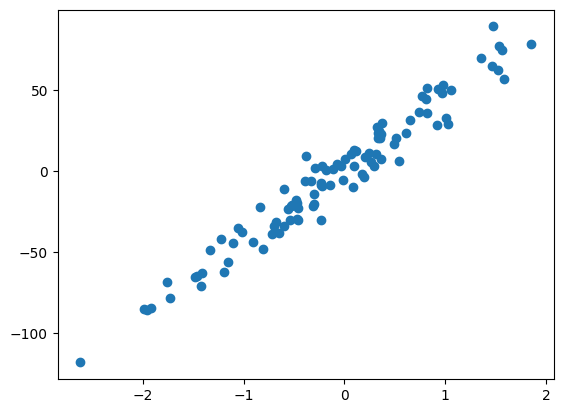

In [14]:
import matplotlib.pyplot as plt
plt.scatter(x,y)

In [15]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [16]:
reg = LinearRegression()
reg.fit(x_train,y_train)
reg.coef_

array([44.24418216])

In [17]:
reg.intercept_

np.float64(0.09922221422587718)

In [18]:
y_pred = reg.predict(x_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.9374151607623286

In [32]:
class MyLinearRegression:

  def __init__(self, learning_rate, epochs):
    self.coef_ = 0.0
    self.intercept_ = 0.0
    self.lr = learning_rate
    self.epochs = epochs

  def fit(self, x, y):
      x = x.ravel()
      y = y.ravel()
      n = len(y)

      for i in range(self.epochs):
          y_pred = self.coef_ * x + self.intercept_

          # Calculate gradients (derivatives of MSE loss)
          loss_slope_b = -2 * np.mean(y - y_pred)
          loss_slope_m = -2 * np.mean((y - y_pred) * x)

          # Update parameters
          self.intercept_ = self.intercept_ - (self.lr * loss_slope_b)
          self.coef_ = self.coef_ - (self.lr * loss_slope_m)

      print(f"Final Intercept: {self.intercept_}, Final Coef: {self.coef_}")

  def predict(self, x):
      return self.coef_ * x.ravel() + self.intercept_

In [33]:
gd = MyLinearRegression(0.01, 1000)
gd.fit(x_train, y_train)

Final Intercept: 0.09921840767934581, Final Coef: 44.24417516050274


In [21]:
gd.fit(x_train,y_train)

[61.04294061 60.87343053 60.92494058 61.19032697 61.09590326 61.01146698
 61.04516217 60.8219549  61.1254075  60.815235   61.1922023  60.91938196
 60.9855479  60.92480712 60.93729742 61.08093905 60.7844439  61.1210477
 61.02460096 60.75510784 61.02610085 60.88652785 61.06780156 61.23147182
 60.99552296 60.6726209  61.01386155 61.18315628 60.86174573 60.97254848
 61.19552728 61.03927024 61.06414098 61.10279016 61.07643875 61.03700497
 60.94208854 60.81711037 60.96263424 60.98272166 61.04139667 60.96135896
 60.9518778  60.93523384 60.95905337 60.760905   60.96237227 60.92973317
 60.97178564 60.91004394 60.93197066 60.91540776 60.97068458 61.04108272
 60.99100118 60.97679894 61.19734793 61.03262304 60.94243581 60.75162144
 60.91226722 61.13210435 61.04519221 60.85051483 61.01087792 60.97074084
 61.01213139 60.86782208 61.11439415 60.99831331 61.16948391 60.89512633
 60.94133166 61.02141521 61.06207239 61.04049948 60.82351004 60.89896578
 61.00843873 61.00063901] 55.12496601192962


In [27]:
gd.predict(x_test)

array([[-12.1732702 , -12.34278027, -12.29127022, ..., -12.31724502,
        -12.20777207, -12.21557179],
       [142.51179959, 142.34228952, 142.39379956, ..., 142.36782476,
        142.47729772, 142.46949799],
       [105.83339895, 105.66388888, 105.71539892, ..., 105.68942412,
        105.79889707, 105.79109735],
       ...,
       [ 74.3811026 ,  74.21159253,  74.26310257, ...,  74.23712778,
         74.34660073,  74.338801  ],
       [101.75088573, 101.58137566, 101.6328857 , ..., 101.6069109 ,
        101.71638385, 101.70858413],
       [ 81.7532811 ,  81.58377103,  81.63528107, ...,  81.60930627,
         81.71877922,  81.7109795 ]])

In [35]:
y_pred_gd = gd.predict(x_test)
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred_gd)
print(f"R2 Score: {score}")

R2 Score: 0.937415134794


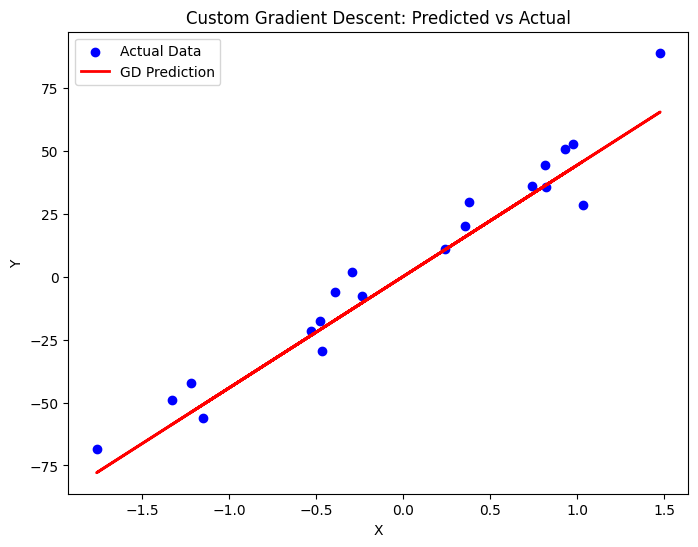

In [36]:
plt.figure(figsize=(8,6))
plt.scatter(x_test, y_test, color='blue', label='Actual Data')
plt.plot(x_test, y_pred_gd, color='red', linewidth=2, label='GD Prediction')
plt.title('Custom Gradient Descent: Predicted vs Actual')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

In [25]:
y_test.shape

(20,)

In [26]:
y_train.shape

(80,)